In [1]:
from google.colab import files
uploaded = files.upload()

Saving frequent_itemsets.csv to frequent_itemsets.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

In [3]:
df = pd.read_csv("frequent_itemsets.csv")
print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (256, 2)


In [4]:
df.head(10)

,support,itemsets
0,0.0568,frozenset({'Air Freshener'})
1,0.0608,frozenset({'Apple 1kg'})
2,0.0600,frozenset({'Banana 1kg'})
3,0.0578,frozenset({'Banana Chips 150g'})
4,0.0604,frozenset({'Bar Soap 125g'})
5,0.1982,frozenset({'Basmati Rice 5kg'})
6,0.0668,frozenset({'Besan 1kg'})
7,0.0588,frozenset({'Brown Bread 400g'})
8,0.0626,frozenset({'Butter 100g'})
9,0.0670,frozenset({'Buttermilk 1L'})


In [5]:
print(df.columns.tolist())

['support', 'itemsets']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   support   256 non-null    float64
 1   itemsets  256 non-null    object 
dtypes: float64(1), object(1)
memory usage: 4.1+ KB


In [7]:
print(df.isnull().sum())

support     0
itemsets    0
dtype: int64


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
def parse_itemset(x):
    x = x.replace("frozenset(", "").rstrip(")")
    return ast.literal_eval(x)
df["parsed_itemsets"] = df["itemsets"].apply(parse_itemset)
df[["support", "parsed_itemsets"]].head(10)

,support,parsed_itemsets
0,0.0568,{Air Freshener}
1,0.0608,{Apple 1kg}
2,0.0600,{Banana 1kg}
3,0.0578,{Banana Chips 150g}
4,0.0604,{Bar Soap 125g}
5,0.1982,{Basmati Rice 5kg}
6,0.0668,{Besan 1kg}
7,0.0588,{Brown Bread 400g}
8,0.0626,{Butter 100g}
9,0.0670,{Buttermilk 1L}


In [10]:
df["itemset_size"] = df["parsed_itemsets"].apply(len)
df[["support", "parsed_itemsets", "itemset_size"]].head(10)

,support,parsed_itemsets,itemset_size
0,0.0568,{Air Freshener},1
1,0.0608,{Apple 1kg},1
2,0.0600,{Banana 1kg},1
3,0.0578,{Banana Chips 150g},1
4,0.0604,{Bar Soap 125g},1
5,0.1982,{Basmati Rice 5kg},1
6,0.0668,{Besan 1kg},1
7,0.0588,{Brown Bread 400g},1
8,0.0626,{Butter 100g},1
9,0.0670,{Buttermilk 1L},1


In [11]:
itemset_counts = df["itemset_size"].value_counts().sort_index()
print(itemset_counts)

itemset_size
1    60
2    78
3    86
4    30
5     2
Name: count, dtype: int64


In [12]:
print("Total frequent itemsets:", len(df))
print("Sum of itemset counts:", itemset_counts.sum())

Total frequent itemsets: 256
Sum of itemset counts: 256


In [13]:
one_itemsets = df[df["itemset_size"] == 1].copy()
one_itemsets = one_itemsets.sort_values(
    by="support",
    ascending=False
)
one_itemsets[["support", "parsed_itemsets"]].head(10)

,support,parsed_itemsets
59,0.2546,{White Bread 400g}
55,0.2540,{Toned Milk 1L}
44,0.2184,{Potato Chips 90g}
14,0.2164,{Cola 750ml}
56,0.2068,{Toor Dal 1kg}
15,0.1996,{Cooking Oil 1L}
5,0.1982,{Basmati Rice 5kg}
13,0.1776,{Choco Cookies 150g}
29,0.1770,{Instant Coffee 100g}
26,0.1706,{Ghee 500ml}


In [14]:
two_itemsets = df[df["itemset_size"] == 2].copy()
two_itemsets = two_itemsets.sort_values(
    by="support",
    ascending=False
)
two_itemsets[["support", "parsed_itemsets"]].head(10)

,support,parsed_itemsets
136,0.2384,"{White Bread 400g, Toned Milk 1L}"
89,0.1974,"{Cola 750ml, Potato Chips 90g}"
100,0.1544,"{Cooking Oil 1L, Toor Dal 1kg}"
70,0.1534,"{Basmati Rice 5kg, Toor Dal 1kg}"
77,0.1520,"{Choco Cookies 150g, Instant Coffee 100g}"
112,0.1468,"{Ghee 500ml, Poha 500g}"
62,0.1462,"{Basmati Rice 5kg, Cooking Oil 1L}"
103,0.1318,"{Hand Sanitizer 200ml, Face Wash 100ml}"
132,0.0584,"{Potato Chips 90g, Toned Milk 1L}"
134,0.0580,"{White Bread 400g, Potato Chips 90g}"


In [15]:
three_itemsets = df[df["itemset_size"] == 3].copy()
three_itemsets = three_itemsets.sort_values(
    by="support",
    ascending=False
)
three_itemsets[["support", "parsed_itemsets"]].head(10)

,support,parsed_itemsets
151,0.1098,"{Basmati Rice 5kg, Cooking Oil 1L, Toor Dal 1kg}"
222,0.0550,"{White Bread 400g, Potato Chips 90g, Toned Mil..."
191,0.0536,"{Cola 750ml, White Bread 400g, Toned Milk 1L}"
188,0.0518,"{Cola 750ml, Potato Chips 90g, Toned Milk 1L}"
190,0.0514,"{Cola 750ml, White Bread 400g, Potato Chips 90g}"
223,0.0512,"{White Bread 400g, Toned Milk 1L, Toor Dal 1kg}"
162,0.0454,"{Basmati Rice 5kg, White Bread 400g, Toned Mil..."
189,0.0434,"{Cola 750ml, Potato Chips 90g, Toor Dal 1kg}"
201,0.0434,"{White Bread 400g, Cooking Oil 1L, Toned Milk 1L}"
220,0.0426,"{White Bread 400g, Toned Milk 1L, Instant Coff..."


In [16]:
four_itemsets = df[df["itemset_size"] == 4].copy()
four_itemsets = four_itemsets.sort_values(
    by="support",
    ascending=False
)
four_itemsets[["support", "parsed_itemsets"]].head(10)

,support,parsed_itemsets
248,0.0484,"{Cola 750ml, White Bread 400g, Potato Chips 90..."
239,0.0374,"{Basmati Rice 5kg, White Bread 400g, Toned Mil..."
244,0.0368,"{Choco Cookies 150g, White Bread 400g, Toned M..."
251,0.0354,"{White Bread 400g, Cooking Oil 1L, Toned Milk ..."
245,0.0330,"{Cola 750ml, Cooking Oil 1L, Potato Chips 90g,..."
229,0.0322,"{Cola 750ml, Basmati Rice 5kg, Potato Chips 90..."
227,0.0308,"{Cola 750ml, Basmati Rice 5kg, Cooking Oil 1L,..."
252,0.0304,"{White Bread 400g, Hand Sanitizer 200ml, Face ..."
236,0.0298,"{Basmati Rice 5kg, White Bread 400g, Cooking O..."
253,0.0292,"{Toned Milk 1L, White Bread 400g, Ghee 500ml, ..."


In [17]:
five_itemsets = df[df["itemset_size"] == 5].copy()
five_itemsets[["support", "parsed_itemsets"]]

,support,parsed_itemsets
254,0.0238,"{Cola 750ml, Potato Chips 90g, Toor Dal 1kg, C..."
255,0.0234,"{Toned Milk 1L, Toor Dal 1kg, Cooking Oil 1L, ..."


In [18]:
top_10 = df.sort_values(
    by="support",
    ascending=False
).head(10)
top_10[["support", "parsed_itemsets"]]

,support,parsed_itemsets
59,0.2546,{White Bread 400g}
55,0.2540,{Toned Milk 1L}
136,0.2384,"{White Bread 400g, Toned Milk 1L}"
44,0.2184,{Potato Chips 90g}
14,0.2164,{Cola 750ml}
56,0.2068,{Toor Dal 1kg}
15,0.1996,{Cooking Oil 1L}
5,0.1982,{Basmati Rice 5kg}
89,0.1974,"{Cola 750ml, Potato Chips 90g}"
13,0.1776,{Choco Cookies 150g}


In [19]:
df["support_percent"] = df["support"] * 100
df[["support", "support_percent", "parsed_itemsets"]].head(10)

,support,support_percent,parsed_itemsets
0,0.0568,5.68,{Air Freshener}
1,0.0608,6.08,{Apple 1kg}
2,0.0600,6.00,{Banana 1kg}
3,0.0578,5.78,{Banana Chips 150g}
4,0.0604,6.04,{Bar Soap 125g}
5,0.1982,19.82,{Basmati Rice 5kg}
6,0.0668,6.68,{Besan 1kg}
7,0.0588,5.88,{Brown Bread 400g}
8,0.0626,6.26,{Butter 100g}
9,0.0670,6.70,{Buttermilk 1L}


In [32]:
print("APRIORI REFERENCE RESULT")
print("-------------------------")
print("Minimum support:", 0.02)
print("1-itemsets:", 60)
print("2-itemsets:", 78)
print("3-itemsets:", 86)
print("4-itemsets:", 30)
print("5-itemsets:", 2)
print("Total frequent itemsets:", 256)

APRIORI REFERENCE RESULT
-------------------------
Minimum support: 0.02
1-itemsets: 60
2-itemsets: 78
3-itemsets: 86
4-itemsets: 30
5-itemsets: 2
Total frequent itemsets: 256


In [33]:
print("FP-GROWTH REFERENCE RESULT")
print("--------------------------")
print("Minimum support:", 0.02)
print("Expected frequent itemsets:", 256)
print("Expected itemset counts:")
print("1-itemsets:", 60)
print("2-itemsets:", 78)
print("3-itemsets:", 86)
print("4-itemsets:", 30)
print("5-itemsets:", 2)

FP-GROWTH REFERENCE RESULT
--------------------------
Minimum support: 0.02
Expected frequent itemsets: 256
Expected itemset counts:
1-itemsets: 60
2-itemsets: 78
3-itemsets: 86
4-itemsets: 30
5-itemsets: 2


In [39]:
planted_patterns = pd.DataFrame({
    "Pattern": [
        "Breakfast Combo",
        "Thali Staples",
        "Snack-Drink Combo",
        "Ghar Breakfast",
        "Tea-Time",
        "Personal Care Restock"
    ],
    "Rule": [
        "Toned Milk 1L → White Bread 400g",
        "Basmati Rice 5kg → Toor Dal 1kg",
        "Potato Chips 90g → Cola 750ml",
        "Ghee 500ml → Poha 500g",
        "Instant Coffee 100g → Choco Cookies 150g",
        "Hand Sanitizer 200ml → Face Wash 100ml"
    ],
    "Support": [
        0.2384,
        0.1534,
        0.1974,
        0.1468,
        0.1520,
        0.1318
    ],
    "Confidence": [
        0.9386,
        0.7740,
        0.9038,
        0.8605,
        0.8588,
        0.7930
    ],
    "Lift": [
        3.69,
        3.74,
        4.18,
        5.07,
        4.84,
        5.05
    ]
})
planted_patterns

,Pattern,Rule,Support,Confidence,Lift
0,Breakfast Combo,Toned Milk 1L → White Bread 400g,0.2384,0.9386,3.69
1,Thali Staples,Basmati Rice 5kg → Toor Dal 1kg,0.1534,0.7740,3.74
2,Snack-Drink Combo,Potato Chips 90g → Cola 750ml,0.1974,0.9038,4.18
3,Ghar Breakfast,Ghee 500ml → Poha 500g,0.1468,0.8605,5.07
4,Tea-Time,Instant Coffee 100g → Choco Cookies 150g,0.1520,0.8588,4.84
5,Personal Care Restock,Hand Sanitizer 200ml → Face Wash 100ml,0.1318,0.7930,5.05


In [40]:
reference_rules_display = reference_rules.copy()
reference_rules_display["support"] = (
    reference_rules_display["support"] * 100
)
reference_rules_display["confidence"] = (
    reference_rules_display["confidence"] * 100
)
reference_rules_display

,antecedent,consequent,support,confidence,lift
0,Toned Milk 1L,White Bread 400g,23.84,93.86,3.69
1,Basmati Rice 1kg,Toor Dal 1kg,15.34,77.40,3.74
2,Potato Chips 90g,Cola 750ml,19.74,90.38,4.18
3,Ghee 500g,Poha 1kg,14.68,86.05,5.07
4,Instant Coffee 100g,Choco Cookies 200g,15.20,85.88,4.84
5,Hand Sanitizer 200ml,Face Wash 100ml,13.18,79.30,5.05


In [38]:
rules_by_lift = reference_rules.sort_values(
    by="lift",
    ascending=False
)
rules_by_lift

,antecedent,consequent,support,confidence,lift
3,Ghee 500g,Poha 1kg,0.1468,0.8605,5.07
5,Hand Sanitizer 200ml,Face Wash 100ml,0.1318,0.7930,5.05
4,Instant Coffee 100g,Choco Cookies 200g,0.1520,0.8588,4.84
2,Potato Chips 90g,Cola 750ml,0.1974,0.9038,4.18
1,Basmati Rice 1kg,Toor Dal 1kg,0.1534,0.7740,3.74
0,Toned Milk 1L,White Bread 400g,0.2384,0.9386,3.69


In [25]:
actionable_rules = reference_rules[
    (reference_rules["support"] > 0.05) &
    (reference_rules["lift"] > 2)
].sort_values(
    by="lift",
    ascending=False
)
actionable_rules

,antecedent,consequent,support,confidence,lift
3,Ghee 500g,Poha 1kg,0.1468,0.8605,5.07
5,Hand Sanitizer 200ml,Face Wash 100ml,0.1318,0.7930,5.05
4,Instant Coffee 100g,Choco Cookies 200g,0.1520,0.8588,4.84
2,Potato Chips 90g,Cola 750ml,0.1974,0.9038,4.18
1,Basmati Rice 1kg,Toor Dal 1kg,0.1534,0.7740,3.74
0,Toned Milk 1L,White Bread 400g,0.2384,0.9386,3.69


In [26]:
print("Support = P(A and B)")
print("Confidence = P(B | A)")
print("Lift = Confidence / P(B)")
print()
print("Lift > 1  -> positive association")
print("Lift = 1  -> independent")
print("Lift < 1  -> negative association")

Support = P(A and B)
Confidence = P(B | A)
Lift = Confidence / P(B)

Lift > 1  -> positive association
Lift = 1  -> independent
Lift < 1  -> negative association


In [27]:
recommendations = pd.DataFrame({
    "Association": [
        "Toned Milk → White Bread",
        "Basmati Rice → Toor Dal",
        "Potato Chips → Cola",
        "Ghee → Poha",
        "Instant Coffee → Choco Cookies",
        "Hand Sanitizer → Face Wash"
    ],
    "Business Action": [
        "Place milk and bread near each other; create breakfast bundle.",
        "Place rice and dal together; create grocery combo offer.",
        "Place chips and cola together; create snack combo.",
        "Place ghee and poha together; create breakfast combo.",
        "Place coffee and cookies together; recommend as a snack bundle.",
        "Place sanitizer and face wash together; recommend as a personal-care combo."
    ]
})
recommendations

,Association,Business Action
0,Toned Milk → White Bread,Place milk and bread near each other; create b...
1,Basmati Rice → Toor Dal,Place rice and dal together; create grocery co...
2,Potato Chips → Cola,Place chips and cola together; create snack co...
3,Ghee → Poha,Place ghee and poha together; create breakfast...
4,Instant Coffee → Choco Cookies,Place coffee and cookies together; recommend a...
5,Hand Sanitizer → Face Wash,Place sanitizer and face wash together; recomm...


In [28]:
control_pair = df[
    df["parsed_itemsets"].apply(
        lambda x: "Banana 1kg" in x and "Shampoo 340ml" in x
    )
]
print("Banana 1kg + Shampoo 340ml itemset found:", not control_pair.empty)
if control_pair.empty:
    print("Control check passed")
else:
    print(control_pair[["support", "parsed_itemsets"]])

Banana 1kg + Shampoo 340ml itemset found: False
Control check passed


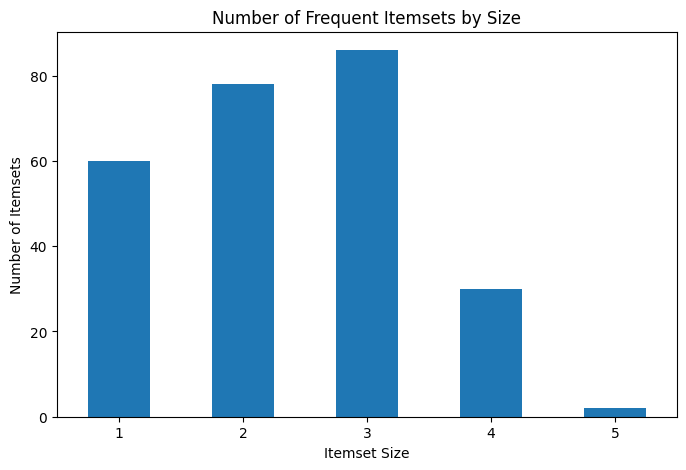

In [29]:
plt.figure(figsize=(8,5))
itemset_counts.plot(kind="bar")
plt.xlabel("Itemset Size")
plt.ylabel("Number of Itemsets")
plt.title("Number of Frequent Itemsets by Size")
plt.xticks(rotation=0)
plt.show()

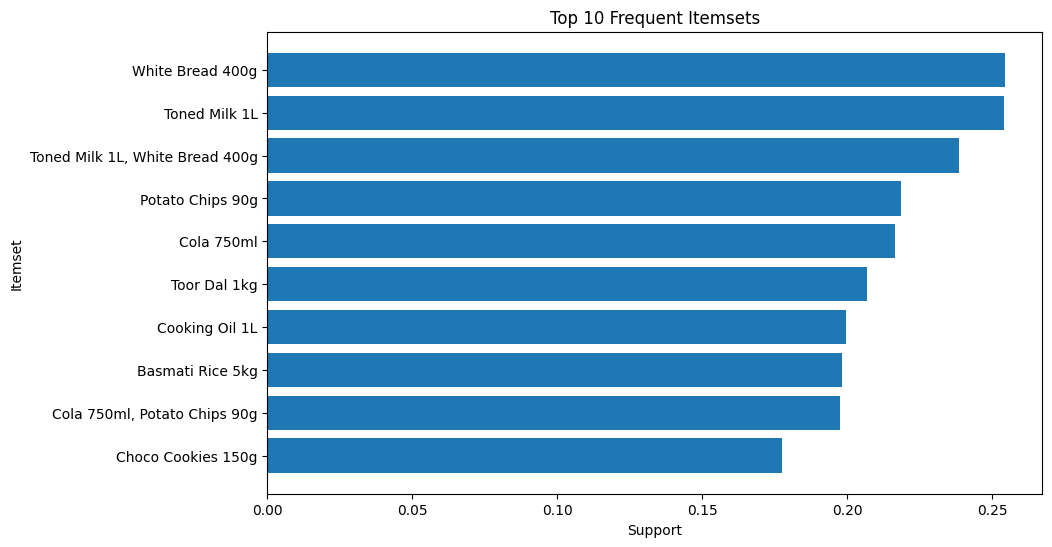

In [30]:
top_10_plot = df.sort_values(
    by="support",
    ascending=False
).head(10).copy()

top_10_plot["label"] = top_10_plot["parsed_itemsets"].apply(
    lambda x: ", ".join(sorted(x))
)
plt.figure(figsize=(10,6))

plt.barh(
    top_10_plot["label"][::-1],
    top_10_plot["support"][::-1]
)
plt.xlabel("Support")
plt.ylabel("Itemset")
plt.title("Top 10 Frequent Itemsets")
plt.show()

In [31]:
print("QUICKCART MARKET BASKET ANALYSIS")
print("--------------------------------")
print("Dataset: frequent_itemsets.csv")
print("Total frequent itemsets:", len(df))
print("Minimum support:", "2%")
print()
print("Frequent Itemsets:")
print("1-itemsets:", (df["itemset_size"] == 1).sum())
print("2-itemsets:", (df["itemset_size"] == 2).sum())
print("3-itemsets:", (df["itemset_size"] == 3).sum())
print("4-itemsets:", (df["itemset_size"] == 4).sum())
print("5-itemsets:", (df["itemset_size"] == 5).sum())
print()
print("Actionable reference rules:", len(actionable_rules))
print("Control pair present:", not control_pair.empty)
print()
print("Business applications:")
print("- Shelf placement")
print("- Bundle deals")
print("- App recommendations")

QUICKCART MARKET BASKET ANALYSIS
--------------------------------
Dataset: frequent_itemsets.csv
Total frequent itemsets: 256
Minimum support: 2%

Frequent Itemsets:
1-itemsets: 60
2-itemsets: 78
3-itemsets: 86
4-itemsets: 30
5-itemsets: 2

Actionable reference rules: 6
Control pair present: False

Business applications:
- Shelf placement
- Bundle deals
- App recommendations
